## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.



2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

4. What difficulties did you encounter in obtaining the data?

5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?




(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


In [1]:
# CLAMP modality extraction setup
import json
from pathlib import Path

import numpy as np

# Update this path if your file is located elsewhere.
DATASET_PATH = Path("/Users/yirantao/Downloads/multimodal/CLAMP/data/CLAMP_dataset_filtered.npz")
OUTPUT_DIR = Path("/Users/yirantao/Downloads/multimodal/outputs/clamp_modalities")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset path: {DATASET_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Dataset path: /Users/yirantao/Downloads/multimodal/CLAMP/data/CLAMP_dataset_filtered.npz
Output directory: /Users/yirantao/Downloads/multimodal/outputs/clamp_modalities


In [2]:
# Extract multimodal subsets from CLAMP_dataset_filtered.npz
raw = np.load(DATASET_PATH, allow_pickle=True)

# Convert object arrays to dense float arrays with shape [N, C, T].
X = np.stack([np.asarray(sample, dtype=np.float32) for sample in raw["dataset"]])
material_labels = np.asarray(raw["material_labels"], dtype=str)
feature_key = raw["feature_key"].item()
label_space = [str(x) for x in raw["label_encoding"].tolist()]

print("Loaded dataset shape [N, C, T]:", X.shape)
print("Available channels:", feature_key)
print("Label space:", label_space)

modality_groups = {
    "force_related": ["Force", "Force diff", "Impedance"],
    "thermal_related": ["Active thermal", "Passive thermal", "Active thermal diff", "Passive thermal diff"],
    "vibration": ["Contact microphone"],
    "proprioception": ["Proprioception"],
}

manifest = {
    "dataset_path": str(DATASET_PATH),
    "num_samples": int(X.shape[0]),
    "sequence_length": int(X.shape[2]),
    "channels": feature_key,
    "saved_files": {},
}


def save_haptic_group(group_name, channel_names):
    idx = [feature_key[name] for name in channel_names]
    group_data = X[:, idx, :]
    output_path = OUTPUT_DIR / f"{group_name}.npz"
    np.savez_compressed(
        output_path,
        data=group_data,
        labels=material_labels,
        channel_names=np.array(channel_names, dtype=object),
        sequence_length=X.shape[2],
    )

    # Save simple summary stats for quick sanity checks.
    stats = {
        "shape": list(group_data.shape),
        "mean": float(np.mean(group_data)),
        "std": float(np.std(group_data)),
        "min": float(np.min(group_data)),
        "max": float(np.max(group_data)),
    }
    manifest["saved_files"][group_name] = {
        "path": str(output_path),
        "channels": channel_names,
        "stats": stats,
    }

    print(f"Saved {group_name}: {group_data.shape} -> {output_path}")


for name, channels in modality_groups.items():
    save_haptic_group(name, channels)


# Extract visual priors (GPT material probability vectors) as a separate modality.
def probs_dict_to_vector(prob_dict, classes):
    vec = np.zeros(len(classes), dtype=np.float32)
    for i, cls in enumerate(classes):
        if cls in prob_dict:
            vec[i] = float(prob_dict[cls])
    return vec


vision_probs = np.stack([probs_dict_to_vector(d, label_space) for d in raw["gpt_probs"]])
vision_path = OUTPUT_DIR / "vision_prior_probs.npz"
np.savez_compressed(
    vision_path,
    probs=vision_probs,
    labels=material_labels,
    class_names=np.array(label_space, dtype=object),
)

manifest["saved_files"]["vision_prior_probs"] = {
    "path": str(vision_path),
    "shape": list(vision_probs.shape),
    "notes": "Per-sample visual material probability vectors from CLAMP GPT priors.",
}

manifest_path = OUTPUT_DIR / "modality_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print(f"Saved visual priors: {vision_probs.shape} -> {vision_path}")
print(f"Saved manifest: {manifest_path}")
print("Modality extraction complete.")

Loaded dataset shape [N, C, T]: (12975, 9, 491)
Available channels: {'Force': 0, 'Active thermal': 1, 'Passive thermal': 2, 'Active thermal diff': 3, 'Passive thermal diff': 4, 'Contact microphone': 5, 'Force diff': 6, 'Proprioception': 7, 'Impedance': 8}
Label space: ['aluminium', 'brass', 'cardboard', 'fabric', 'foam', 'glass', 'hard_plastic', 'paper', 'porcelain', 'rubber', 'soft_plastic', 'steel', 'vegetable_matter', 'wood']
Saved force_related: (12975, 3, 491) -> /Users/yirantao/Downloads/multimodal/outputs/clamp_modalities/force_related.npz
Saved thermal_related: (12975, 4, 491) -> /Users/yirantao/Downloads/multimodal/outputs/clamp_modalities/thermal_related.npz
Saved vibration: (12975, 1, 491) -> /Users/yirantao/Downloads/multimodal/outputs/clamp_modalities/vibration.npz
Saved proprioception: (12975, 1, 491) -> /Users/yirantao/Downloads/multimodal/outputs/clamp_modalities/proprioception.npz
Saved visual priors: (12975, 14) -> /Users/yirantao/Downloads/multimodal/outputs/clamp_mo

(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [3]:
# Packages for visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")


def load_clamp_for_visualization(npz_path, sample_size=2500, random_state=42):
    """Load CLAMP filtered data and return sampled arrays for visualization."""
    raw = np.load(npz_path, allow_pickle=True)

    X = np.stack([np.asarray(sample, dtype=np.float32) for sample in raw["dataset"]])
    labels = np.asarray(raw["material_labels"], dtype=str)
    feature_key = raw["feature_key"].item()

    rng = np.random.default_rng(random_state)
    sample_size = min(sample_size, len(X))
    idx = rng.choice(len(X), size=sample_size, replace=False)

    return X[idx], labels[idx], feature_key


# Reuse the path defined in the modality extraction section.
X_vis, y_vis, feature_key_vis = load_clamp_for_visualization(DATASET_PATH)
feature_names_vis = [k for k, _ in sorted(feature_key_vis.items(), key=lambda item: item[1])]

print("Visualization subset shape [N, C, T]:", X_vis.shape)
print("Features:", feature_names_vis)

/var/folders/nq/5pz_6sx54gq6g1gg97_gr5480000gn/T/ipykernel_54279/1511231078.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Visualization subset shape [N, C, T]: (2500, 9, 491)
Features: ['Force', 'Active thermal', 'Passive thermal', 'Active thermal diff', 'Passive thermal diff', 'Contact microphone', 'Force diff', 'Proprioception', 'Impedance']


# Data Distribution

In [4]:
def visualize_data_distribution(
    X,
    labels,
    channels=("Force", "Active thermal", "Contact microphone"),
    perplexity=35,
    n_iter=1000,
    random_state=42,
):
    """Visualize global sample distribution with t-SNE on selected channels."""
    channel_idx = [feature_key_vis[c] for c in channels]

    # Aggregate each selected channel into compact statistics.
    feats = []
    for idx in channel_idx:
        series = X[:, idx, :]
        feats.extend([
            np.mean(series, axis=1),
            np.std(series, axis=1),
            np.max(series, axis=1),
            np.min(series, axis=1),
            np.quantile(series, 0.75, axis=1),
            np.quantile(series, 0.25, axis=1),
        ])

    F = np.column_stack(feats)
    F = StandardScaler().fit_transform(F)

    # PCA before t-SNE helps stability and speed.
    pca_dim = min(20, F.shape[1])
    F_pca = PCA(n_components=pca_dim, random_state=random_state).fit_transform(F)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=n_iter,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    Z = tsne.fit_transform(F_pca)

    plot_df = pd.DataFrame({"TSNE-1": Z[:, 0], "TSNE-2": Z[:, 1], "label": labels})

    plt.figure(figsize=(11, 8))
    top_labels = plot_df["label"].value_counts().head(8).index
    mask = plot_df["label"].isin(top_labels)

    sns.scatterplot(
        data=plot_df[mask],
        x="TSNE-1",
        y="TSNE-2",
        hue="label",
        s=18,
        alpha=0.8,
        linewidth=0,
        palette="tab10",
    )
    plt.title("Data Distribution (t-SNE on multimodal summary features)")
    plt.legend(title="Top-8 materials", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return plot_df

# Samples

In [5]:
def visualize_samples(X, labels, feature_names, num_samples=6, random_state=7):
    """Visualize random sample trajectories from multiple channels."""
    if num_samples > len(X):
        raise ValueError(f"num_samples ({num_samples}) cannot exceed dataset size ({len(X)}).")

    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X), size=num_samples, replace=False)

    channels_to_plot = [
        feature_key_vis["Force"],
        feature_key_vis["Active thermal"],
        feature_key_vis["Contact microphone"],
    ]
    channel_titles = [feature_names[i] for i in channels_to_plot]

    fig, axes = plt.subplots(num_samples, len(channels_to_plot), figsize=(14, 2.6 * num_samples), sharex=True)
    if num_samples == 1:
        axes = np.array([axes])

    for row, sample_idx in enumerate(idx):
        for col, ch in enumerate(channels_to_plot):
            ax = axes[row, col]
            ax.plot(X[sample_idx, ch, :], linewidth=1.0)
            if row == 0:
                ax.set_title(channel_titles[col])
            if col == 0:
                ax.set_ylabel(labels[sample_idx], fontsize=9)

    fig.suptitle("Sample-level Multimodal Signals", y=1.02)
    plt.tight_layout()
    plt.show()

    return idx

# Input Distribution

In [6]:
def visualize_input_distribution(X, labels, feature_names):
    """Visualize channel-level input distributions and label balance."""

    # Distribution over material labels.
    plt.figure(figsize=(12, 4))
    counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    sns.barplot(x=counts.index, y=counts.values, color="#4C72B0")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title("Material Label Distribution (Visualization Subset)")
    plt.tight_layout()
    plt.show()

    # Input statistics per channel.
    channel_means = X.mean(axis=2)  # [N, C]
    df = pd.DataFrame(channel_means, columns=feature_names)

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df, orient="h", showfliers=False)
    plt.title("Input Distribution by Channel (mean over time per sample)")
    plt.xlabel("Channel value")
    plt.tight_layout()
    plt.show()

    # Creative visualization: correlation heatmap between channel summaries.
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Channel Correlation Heatmap")
    plt.tight_layout()
    plt.show()

    return counts, corr

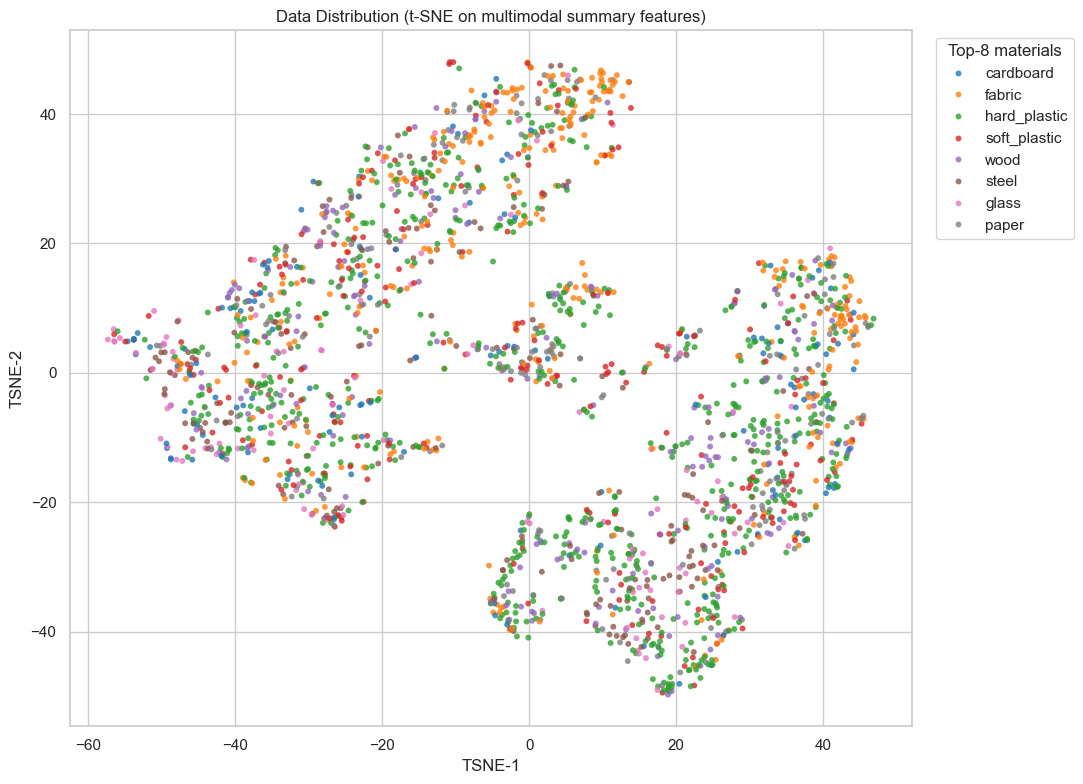

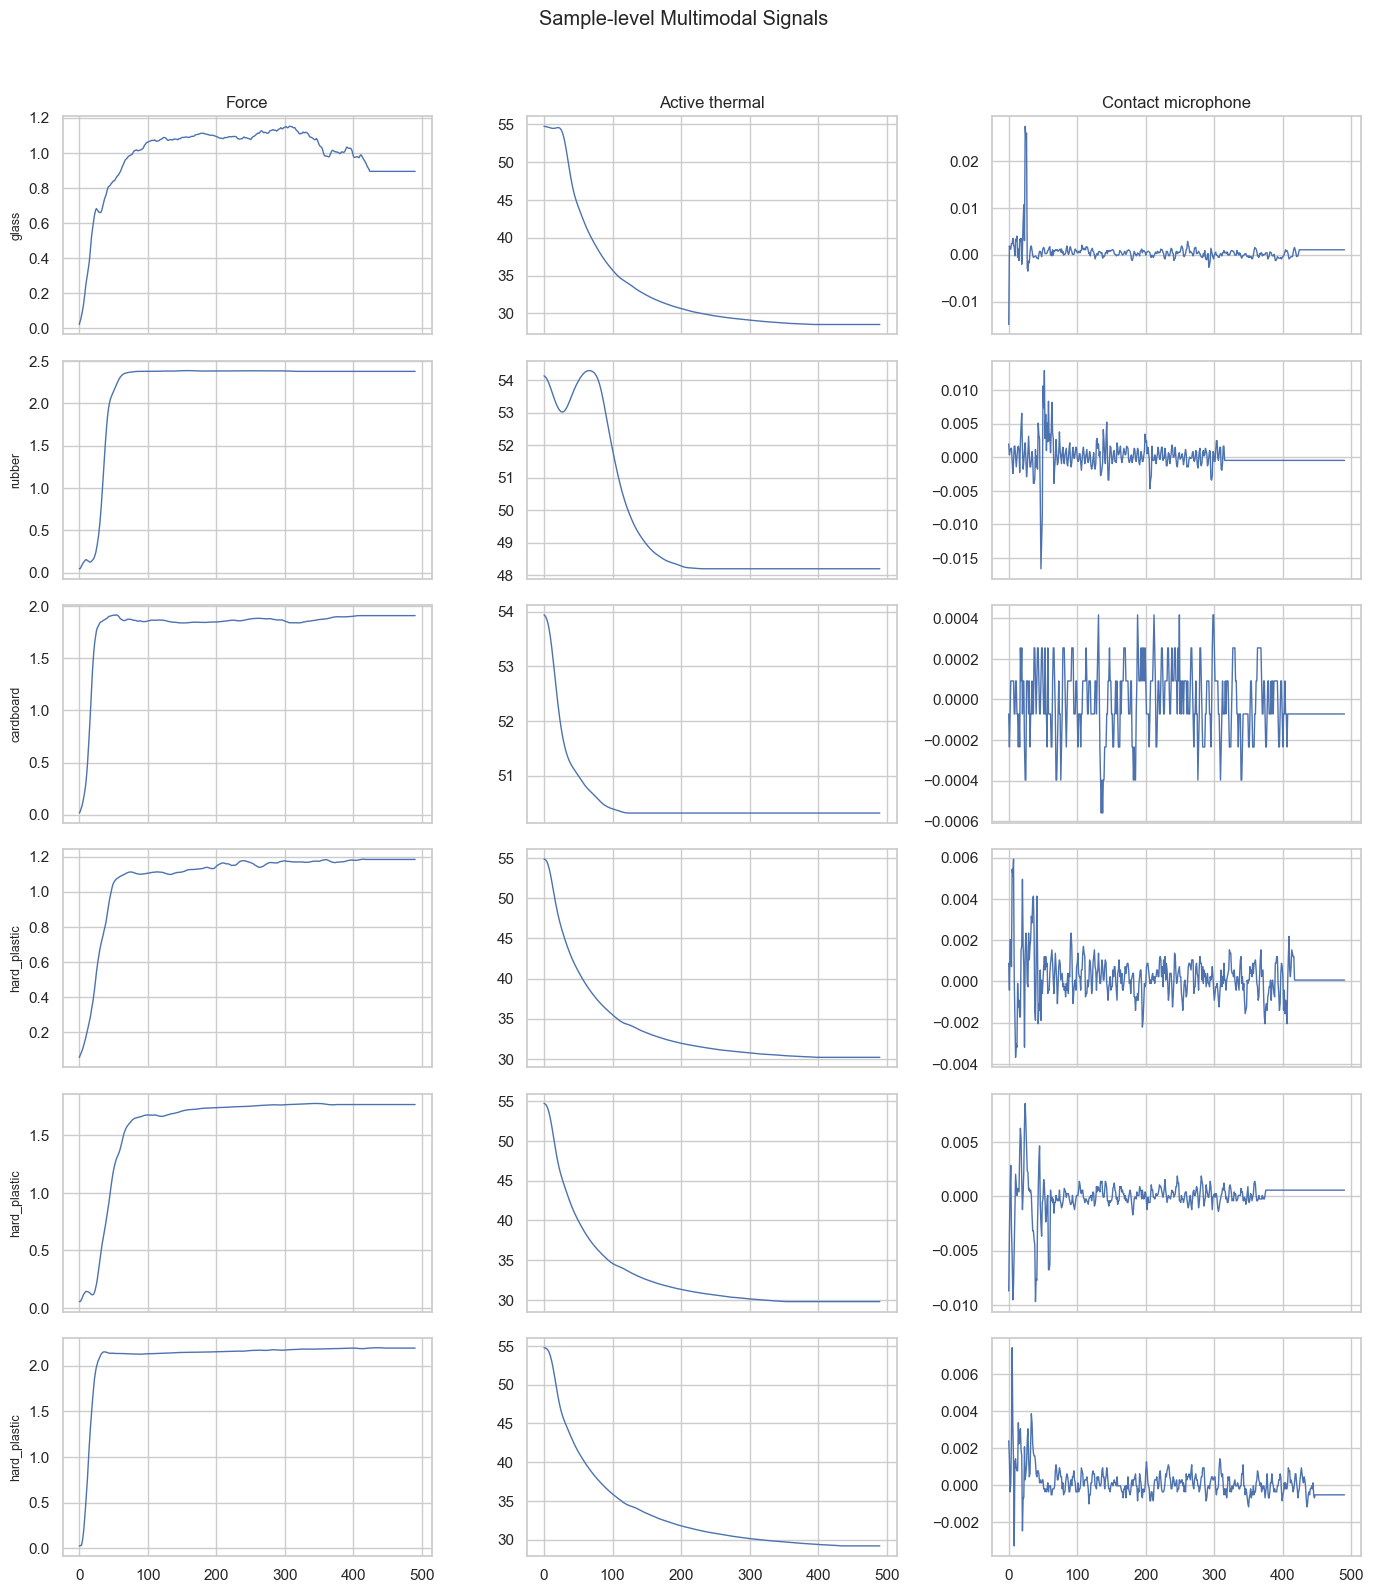

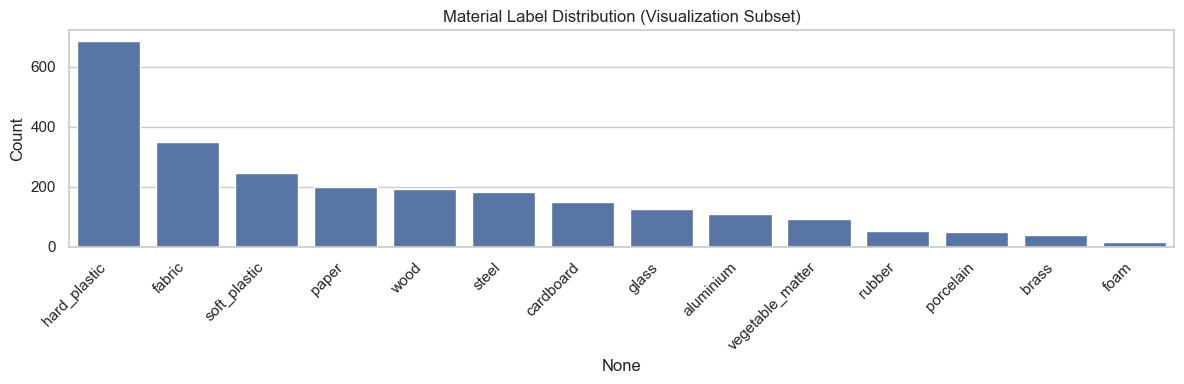

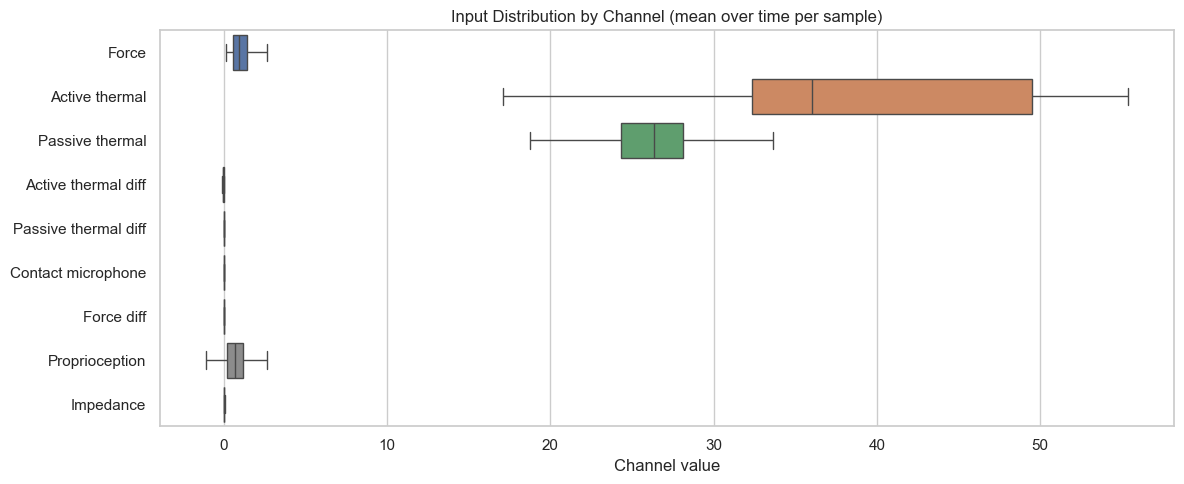

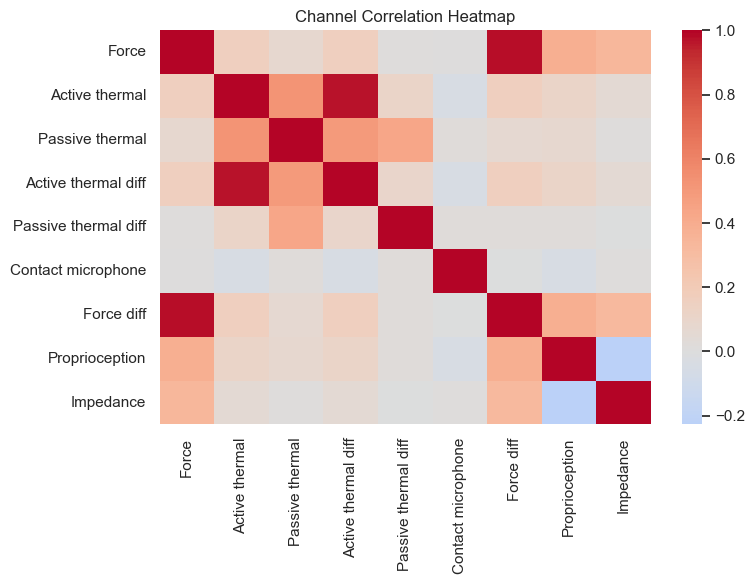

In [7]:
# Run all visualizations for this section
_ = visualize_data_distribution(
    X_vis,
    y_vis,
    channels=("Force", "Active thermal", "Contact microphone"),
    perplexity=35,
    n_iter=1000,
)

_ = visualize_samples(X_vis, y_vis, feature_names_vis, num_samples=6)

_ = visualize_input_distribution(X_vis, y_vis, feature_names_vis)

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [9]:
# Evaluation metrics for multimodal material recognition
from typing import Dict

import numpy as np
from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef


def _validate_inputs(predictions, ground_truths):
    """Validate prediction and target arrays before metric computation."""
    y_pred = np.asarray(predictions)
    y_true = np.asarray(ground_truths)

    if y_true.size == 0:
        raise ValueError("No ground-truth labels were provided.")
    if y_pred.size == 0:
        raise ValueError("No predictions were provided.")
    if y_pred.shape[0] != y_true.shape[0]:
        raise ValueError(
            f"Prediction/ground-truth length mismatch: {y_pred.shape[0]} vs {y_true.shape[0]}"
        )

    return y_pred, y_true


def accuracy_metric(predictions, ground_truths) -> float:
    """Compute standard classification accuracy."""
    y_pred, y_true = _validate_inputs(predictions, ground_truths)
    return float(np.mean(y_pred == y_true))


def macro_f1_metric(predictions, ground_truths) -> float:
    """Compute macro-F1, which weights each class equally."""
    y_pred, y_true = _validate_inputs(predictions, ground_truths)
    return float(f1_score(y_true, y_pred, average="macro"))


def balanced_accuracy_metric(predictions, ground_truths) -> float:
    """Compute balanced accuracy (mean recall over classes)."""
    y_pred, y_true = _validate_inputs(predictions, ground_truths)
    return float(balanced_accuracy_score(y_true, y_pred))


def mcc_metric(predictions, ground_truths) -> float:
    """Compute Matthews correlation coefficient (robust under class imbalance)."""
    y_pred, y_true = _validate_inputs(predictions, ground_truths)
    return float(matthews_corrcoef(y_true, y_pred))


def evaluate_all_metrics(predictions, ground_truths) -> Dict[str, float]:
    """Return all metrics used in this project."""
    return {
        "accuracy": accuracy_metric(predictions, ground_truths),
        "macro_f1": macro_f1_metric(predictions, ground_truths),
        "balanced_accuracy": balanced_accuracy_metric(predictions, ground_truths),
        "mcc": mcc_metric(predictions, ground_truths),
    }


# Keep compatibility with the provided template function name.
def evaluation_metric(predictions, ground_truths):
    return accuracy_metric(predictions, ground_truths)


# Sanity-check usage only (NO trained model yet).
# This block verifies that metric functions run correctly with toy predictors.
if "y_vis" in globals():
    y_true = np.asarray(y_vis)

    # Toy baseline 1: always predict the majority class.
    majority_label = np.unique(y_true)[np.argmax([np.sum(y_true == c) for c in np.unique(y_true)])]
    y_pred_majority = np.full_like(y_true, fill_value=majority_label)

    # Toy baseline 2: sample labels from the empirical class prior.
    rng = np.random.default_rng(42)
    classes, counts = np.unique(y_true, return_counts=True)
    probs = counts / counts.sum()
    y_pred_random = rng.choice(classes, size=len(y_true), p=probs)

    rows = [
        {"predictor": "majority_label_toy", **evaluate_all_metrics(y_pred_majority, y_true)},
        {"predictor": "random_prior_toy", **evaluate_all_metrics(y_pred_random, y_true)},
    ]

    results_df = pd.DataFrame(rows)
    print("Sanity check metrics (toy predictors, not trained models):")
    try:
        display(results_df)
    except NameError:
        print(results_df.to_string(index=False))
    print("Use these functions with real model outputs later: evaluate_all_metrics(y_pred, y_true)")


Sanity check metrics (toy predictors, not trained models):


,predictor,accuracy,macro_f1,balanced_accuracy,mcc
0,majority_label_toy,0.2748,0.030795,0.071429,0.00000
1,random_prior_toy,0.1228,0.064305,0.064340,-0.01376


Use these functions with real model outputs later: evaluate_all_metrics(y_pred, y_true)


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [ ]:
# BONUS CODE HERE


(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!